<a href="https://colab.research.google.com/github/anabiarochar/Mestrado_AlgoritmosProgramacao/blob/main/Projeto2/Projeto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Projeto2

##Implementação das Árvores

In [1]:
import pandas as pd
!pip install gdown

In [2]:
# Google Drive - ID do arquivo
file_id = '1fsbd9Zm7h9k4oxa0baM0EJ7ChAZhiSir'

# Arquivo Output
output_filename = 'dataset.csv'

# Download do arquivo usando gdown
!gdown --id {file_id} -O {output_filename}

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1fsbd9Zm7h9k4oxa0baM0EJ7ChAZhiSir
To: /content/dataset.csv
100% 6.71M/6.71M [00:00<00:00, 88.0MB/s]


In [5]:
df = pd.read_csv(output_filename)
display(df.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,821198084644106078,Bright and Peaceful Leblon Loft,84350716,Katrina,NaN,Leblon,-22.982818,-43.222457,Entire home/apt,580.0,2,86,2025-09-19,2.72,1,82,40,NaN
1,821198370698658112,Copacabana 100% reformado.,4347269,Patrick,NaN,Copacabana,-22.984090,-43.191770,Entire home/apt,1900.0,5,0,NaN,NaN,2,364,0,NaN
2,821200521820144734,hambiente familia,499903412,Vanessa,NaN,Pavuna,-22.814911,-43.379011,Entire home/apt,700.0,1,0,NaN,NaN,2,365,0,NaN
3,821213014263313420,Amazing en suite bedroom Leblon,449763717,Alvaro,NaN,Leblon,-22.981910,-43.225990,Private room,NaN,2,3,2024-05-02,0.10,2,0,0,NaN
4,821223043903573522,Incrível apartamento frente mar,25961210,Katia,NaN,Barra da Tijuca,-23.010000,-43.344820,Entire home/apt,500.0,2,11,2025-08-26,0.60,1,234,10,NaN


### Implementando a Árvore Binária de Busca (BST)

In [3]:
import pandas as pd
from collections import deque

class BSTNode:
    def __init__(self, host_id, info_dict):
        self.host_id = int(host_id)
        self.info = info_dict
        self.left = None
        self.right = None

class BinarySearchTree:
    def __init__(self):
        self.root = None

    def insert(self, host_id, info_dict):
        """Versão Iterativa: Mais segura para grandes volumes de dados."""
        new_node = BSTNode(host_id, info_dict)
        if self.root is None:
            self.root = new_node
            return

        current = self.root
        while True:
            if new_node.host_id < current.host_id:
                if current.left is None:
                    current.left = new_node
                    break
                current = current.left
            else:
                # host_ids iguais ou maiores vão para a direita
                if current.right is None:
                    current.right = new_node
                    break
                current = current.right

    def search_by_host_id(self, target_host_id):
        """Busca Iterativa: Evita limites de recursão do Python."""
        target = int(target_host_id)
        current = self.root

        while current is not None:
            if target == current.host_id:
                return current.info
            elif target < current.host_id:
                current = current.left
            else:
                current = current.right
        return None

    def get_height_iterative(self):
        """Calcula a altura de forma iterativa para evitar erros em árvores profundas."""
        if not self.root: return 0
        queue = deque([(self.root, 1)])
        max_h = 0
        while queue:
            node, h = queue.popleft()
            max_h = max(max_h, h)
            if node.left: queue.append((node.left, h + 1))
            if node.right: queue.append((node.right, h + 1))
        return max_h

    def delete(self, host_id_to_delete):
        """Remove um nó da BST."""
        host_id_to_delete = int(host_id_to_delete)
        self.root = self._delete_recursive(self.root, host_id_to_delete)

    def _delete_recursive(self, node, host_id_to_delete):
        if node is None:
            return node

        if host_id_to_delete < node.host_id:
            node.left = self._delete_recursive(node.left, host_id_to_delete)
        elif host_id_to_delete > node.host_id:
            node.right = self._delete_recursive(node.right, host_id_to_delete)
        else:
            # Nó a ser deletado encontrado
            # Caso 1: Nó com 0 ou 1 filho
            if node.left is None:
                return node.right
            elif node.right is None:
                return node.left

            # Caso 2: Nó com 2 filhos
            # Encontra o sucessor in-order (menor nó na subárvore direita)
            temp = self._min_value_node(node.right)
            node.host_id = temp.host_id
            node.info = temp.info
            node.right = self._delete_recursive(node.right, temp.host_id)
        return node

    def _min_value_node(self, node):
        current = node
        while current.left is not None:
            current = current.left
        return current

# --- Processamento ---

df = pd.read_csv('dataset.csv')
df_clean = df.dropna(subset=['price']).copy()

bst_price = BinarySearchTree()

print(f"Construindo árvore com {len(df_clean)} registros...")


for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'],
        'host_name': row['host_name'],
        'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'],
        'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'],
        'price': row['price']
    }
    bst_price.insert(row['host_id'], data_dict)

print("Árvore de Host IDs construída com sucesso.")

Construindo árvore com 38670 registros...
Árvore de Host IDs construída com sucesso.


In [ ]:
import sys

def get_deep_memory_usage(tree_root):
    """
    Estima o uso de memória (em bytes) de uma árvore, somando o tamanho de cada nó
    e seus atributos principais (host_id, dicionário de info e seus conteúdos, altura).
    Evita a contagem duplicada de objetos referenciados.
    """
    if not tree_root:
        return 0

    total_memory = 0
    nodes_to_visit = [tree_root]
    # Conjunto para rastrear IDs de objetos já visitados para evitar contagem duplicada
    visited_objects = set()

    while nodes_to_visit:
        current_node = nodes_to_visit.pop()

        if id(current_node) in visited_objects:
            continue
        visited_objects.add(id(current_node))

        total_memory += sys.getsizeof(current_node) # Tamanho do objeto Node em si

        # Adicionar tamanho do int 'host_id'
        if id(current_node.host_id) not in visited_objects:
            total_memory += sys.getsizeof(current_node.host_id)
            visited_objects.add(id(current_node.host_id))

        # Adicionar tamanho do dicionário 'info' em si
        if id(current_node.info) not in visited_objects:
            total_memory += sys.getsizeof(current_node.info)
            visited_objects.add(id(current_node.info))

            # Adicionar tamanho dos conteúdos do dicionário 'info' (chaves e valores)
            for key, value in current_node.info.items():
                if id(key) not in visited_objects:
                    total_memory += sys.getsizeof(key)
                    visited_objects.add(id(key))
                if id(value) not in visited_objects:
                    total_memory += sys.getsizeof(value)
                    visited_objects.add(id(value))

        # Adicionar tamanho do atributo 'height' (apenas para nós AVL)
        if hasattr(current_node, 'height') and id(current_node.height) not in visited_objects:
            total_memory += sys.getsizeof(current_node.height)
            visited_objects.add(id(current_node.height))

        if current_node.left:
            nodes_to_visit.append(current_node.left)
        if current_node.right:
            nodes_to_visit.append(current_node.right)

    return total_memory

### Implementando AVL

In [4]:
import pandas as pd
import sys

# Aumentamos o limite de recursão para a inserção inicial no dataset grande
sys.setrecursionlimit(50000)

class AVLNode:
    def __init__(self, host_id, info_dict):
        self.host_id = int(host_id)
        self.info = info_dict
        self.left = None
        self.right = None
        self.height = 1

class AVLTree:
    def get_height(self, node):
        return node.height if node else 0

    def get_balance(self, node):
        return self.get_height(node.left) - self.get_height(node.right) if node else 0

    def right_rotate(self, y):
        x = y.left
        T2 = x.right
        x.right = y
        y.left = T2
        y.height = 1 + max(self.get_height(y.left), self.get_height(y.right))
        x.height = 1 + max(self.get_height(x.left), self.get_height(x.right))
        return x

    def left_rotate(self, x):
        y = x.right
        T2 = y.left
        y.left = x
        x.right = T2
        x.height = 1 + max(self.get_height(x.left), self.get_height(x.right))
        y.height = 1 + max(self.get_height(y.left), self.get_height(y.right))
        return y

    def insert(self, root, host_id, info_dict):
        """Insere um nó e rebalanceia a árvore automaticamente."""
        if not root:
            return AVLNode(host_id, info_dict)

        # Inserção padrão BST
        host_id_val = int(host_id)
        if host_id_val < root.host_id:
            root.left = self.insert(root.left, host_id_val, info_dict)
        else:
            # host_ids iguais ou maiores vão para a direita
            root.right = self.insert(root.right, host_id_val, info_dict)

        # Atualiza a altura do nó pai
        root.height = 1 + max(self.get_height(root.left), self.get_height(root.right))

        # Calcula o fator de balanço
        balance = self.get_balance(root)

        # Casos de Rebalanceamento (Rotações)
        # 1. Esquerda-Esquerda
        if balance > 1 and host_id_val < root.left.host_id:
            return self.right_rotate(root)
        # 2. Direita-Direita
        if balance < -1 and host_id_val >= root.right.host_id:
            return self.left_rotate(root)
        # 3. Esquerda-Direita
        if balance > 1 and host_id_val >= root.left.host_id:
            root.left = self.left_rotate(root.left)
            return self.right_rotate(root)
        # 4. Direita-Esquerda
        if balance < -1 and host_id_val < root.right.host_id:
            root.right = self.right_rotate(root.right)
            return self.left_rotate(root)

        return root

    def search_by_host_id(self, root, target_host_id):
        """Busca iterativa (mais eficiente) na árvore AVL."""
        target = int(target_host_id)
        current = root
        while current:
            if target == current.host_id:
                return current.info
            elif target < current.host_id:
                current = current.left
            else:
                current = current.right
        return None

    def delete(self, root, host_id_to_delete):
        """Remove um nó da AVL e rebalanceia."""
        if not root:
            return root

        host_id_to_delete = int(host_id_to_delete)

        if host_id_to_delete < root.host_id:
            root.left = self.delete(root.left, host_id_to_delete)
        elif host_id_to_delete > root.host_id:
            root.right = self.delete(root.right, host_id_to_delete)
        else:
            # Nó a ser deletado encontrado
            # Caso 1: Nó com 0 ou 1 filho
            if not root.left:
                temp = root.right
                root = None
                return temp
            elif not root.right:
                temp = root.left
                root = None
                return temp

            # Caso 2: Nó com 2 filhos
            # Encontra o sucessor in-order (menor nó na subárvore direita)
            temp = self._min_value_node(root.right)
            root.host_id = temp.host_id
            root.info = temp.info
            root.right = self.delete(root.right, temp.host_id)

        if not root:
            return root

        # Atualiza a altura do nó pai
        root.height = 1 + max(self.get_height(root.left), self.get_height(root.right))

        # Calcula o fator de balanço
        balance = self.get_balance(root)

        # Casos de Rebalanceamento (Rotações)
        # Esquerda-Esquerda
        if balance > 1 and self.get_balance(root.left) >= 0:
            return self.right_rotate(root)
        # Esquerda-Direita
        if balance > 1 and self.get_balance(root.left) < 0:
            root.left = self.left_rotate(root.left)
            return self.right_rotate(root)
        # Direita-Direita
        if balance < -1 and self.get_balance(root.right) <= 0:
            return self.left_rotate(root)
        # Direita-Esquerda
        if balance < -1 and self.get_balance(root.right) > 0:
            root.right = self.right_rotate(root.right)
            return self.left_rotate(root)

        return root

    def _min_value_node(self, node):
        current = node
        while current.left is not None:
            current = current.left
        return current

# --- Execução Principal ---

df = pd.read_csv('dataset.csv')
df_clean = df.dropna(subset=['price']).copy()

avl = AVLTree()
root = None

print(f"Inserindo {len(df_clean)} registros na Árvore AVL... (Isso pode levar alguns segundos)")

for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'],
        'host_name': row['host_name'],
        'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'],
        'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'],
        'price': row['price']
    }
    root = avl.insert(root, row['host_id'], data_dict)

Inserindo 38670 registros na Árvore AVL... (Isso pode levar alguns segundos)


##Comparativos entre as Árvores

### Comparativo de Altura das Árvores

In [5]:
h_bst = bst_price.get_height_iterative()
h_avl = avl.get_height(root)

print("\n=== Comparativo de Alturas ===")
print(f"Altura BST Simples: {h_bst}")
print(f"Altura Árvore AVL:  {h_avl}")
print(f"Ganho de Eficiência: {round((1 - h_avl/h_bst)*100, 2)}%")


=== Comparativo de Alturas ===
Altura BST Simples: 364
Altura Árvore AVL:  19
Ganho de Eficiência: 94.78%


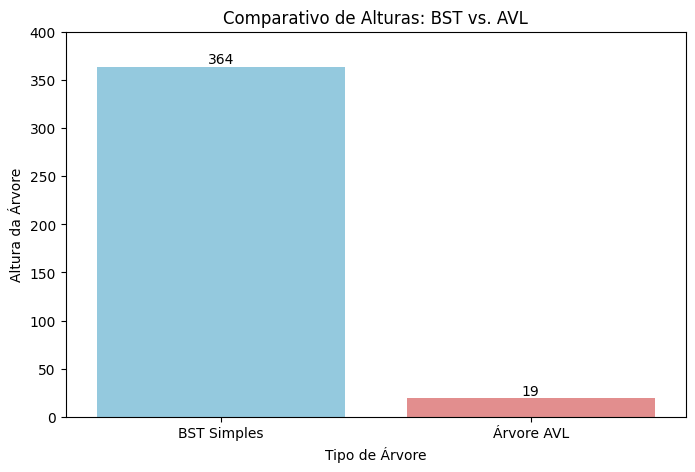

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o gráfico
heights = {'BST Simples': h_bst, 'Árvore AVL': h_avl}
tree_types = list(heights.keys())
values = list(heights.values())

# Criar o gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x=tree_types, y=values, palette=['skyblue', 'lightcoral'], hue=tree_types, legend=False)

# Adicionar títulos e rótulos
plt.title('Comparativo de Alturas: BST vs. AVL')
plt.ylabel('Altura da Árvore')
plt.xlabel('Tipo de Árvore')

# Adicionar os valores nas barras
for index, value in enumerate(values):
    plt.text(index, value + 0.1, str(value), ha='center', va='bottom')

plt.ylim(0, max(values) * 1.1) # Ajustar o limite Y para melhor visualização
plt.show()

### Comparativo de Tempo de Busca Médio (1000 Testes Aleatórios)

In [12]:
import random
import time # Importar time para usar time.time()

num_tests = 1000
times_bst = []
times_avl = []

# Gerar uma lista de host_ids aleatórios para buscar
search_host_ids = df_clean['host_id'].sample(num_tests, random_state=42).tolist()

print(f"Realizando {num_tests} buscas aleatórias...")

for i in range(num_tests):
    target_host_id = search_host_ids[i]

    # Medir tempo de busca na BST
    start_time_bst = time.time()
    bst_price.search_by_host_id(target_host_id)
    end_time_bst = time.time()
    times_bst.append((end_time_bst - start_time_bst) * 1000) # em milissegundos

    # Medir tempo de busca na AVL
    start_time_avl = time.time()
    avl.search_by_host_id(root, target_host_id)
    end_time_avl = time.time()
    times_avl.append((end_time_avl - start_time_avl) * 1000) # em milissegundos

avg_time_bst = sum(times_bst) / num_tests
avg_time_avl = sum(times_avl) / num_tests

print(f"\n=== Comparativo de Tempo de Busca Médio para {num_tests} host_ids aleatórios ===")
print(f"Tempo médio de busca na BST: {avg_time_bst:.4f} ms")
print(f"Tempo médio de busca na AVL: {avg_time_avl:.4f} ms")

Realizando 1000 buscas aleatórias...

=== Comparativo de Tempo de Busca Médio para 1000 host_ids aleatórios ===
Tempo médio de busca na BST: 0.0087 ms
Tempo médio de busca na AVL: 0.0054 ms


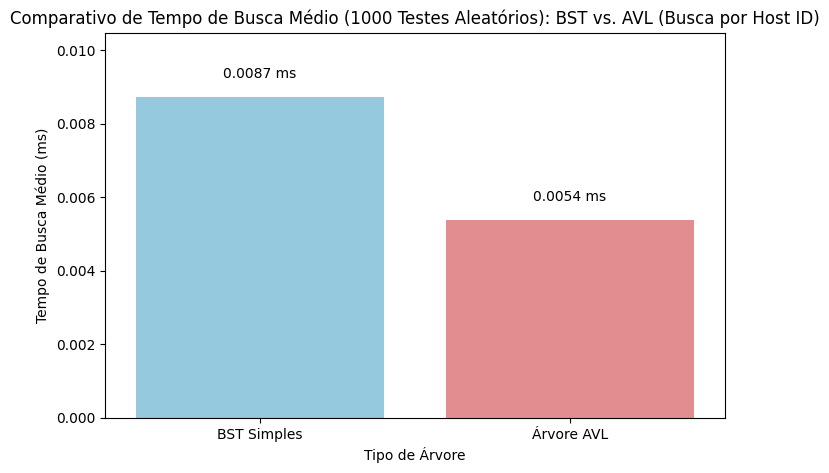

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o gráfico de tempo de busca médio
times_avg = {'BST Simples': avg_time_bst, 'Árvore AVL': avg_time_avl}
tree_types_avg_search = list(times_avg.keys())
avg_search_values = list(times_avg.values())

# Criar o gráfico de barras para tempo de busca médio
plt.figure(figsize=(8, 5))
sns.barplot(x=tree_types_avg_search, y=avg_search_values, palette=['skyblue', 'lightcoral'], hue=tree_types_avg_search, legend=False)

# Adicionar títulos e rótulos
plt.title(f'Comparativo de Tempo de Busca Médio ({num_tests} Testes Aleatórios): BST vs. AVL (Busca por Host ID)')
plt.ylabel('Tempo de Busca Médio (ms)')
plt.xlabel('Tipo de Árvore')

# Adicionar os valores nas barras
for index, value in enumerate(avg_search_values):
    plt.text(index, value + (max(avg_search_values) * 0.05), f'{value:.4f} ms', ha='center', va='bottom')

plt.ylim(0, max(avg_search_values) * 1.2) # Ajustar o limite Y para melhor visualização
plt.show()

### Gráfico de Dispersão dos Tempos de Busca Individuais

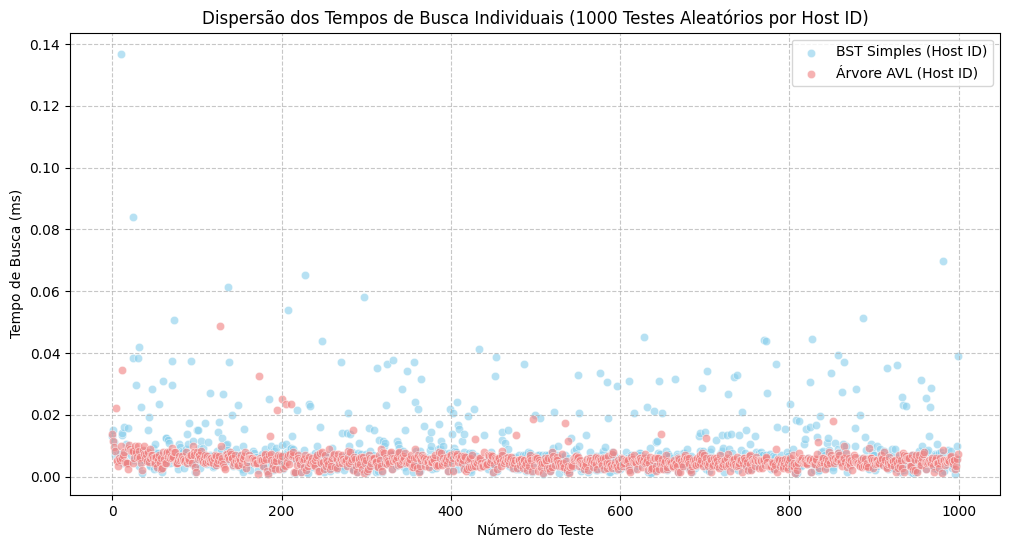

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criar um índice para os testes
test_indices = np.arange(num_tests)

plt.figure(figsize=(12, 6))

sns.scatterplot(x=test_indices, y=times_bst, label='BST Simples (Host ID)', alpha=0.6, color='skyblue')
sns.scatterplot(x=test_indices, y=times_avl, label='Árvore AVL (Host ID)', alpha=0.6, color='lightcoral')

plt.title('Dispersão dos Tempos de Busca Individuais (1000 Testes Aleatórios por Host ID)')
plt.xlabel('Número do Teste')
plt.ylabel('Tempo de Busca (ms)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Tabela de Tempos de Busca Individuais

In [15]:
import pandas as pd

# Criar um DataFrame com os tempos de busca individuais
times_df = pd.DataFrame({
    'Teste': np.arange(num_tests) + 1, # Teste indexado de 1 a num_tests
    'Tempo BST (ms)': times_bst,
    'Tempo AVL (ms)': times_avl,
    'Host ID Buscado': search_host_ids # Adicionar a coluna de host_id buscado
})

# Exibir as primeiras e últimas 5 linhas da tabela para uma visão geral
print("Primeiras 5 linhas:")
display(times_df.head())

print("\nÚltimas 5 linhas:")
display(times_df.tail())

Primeiras 5 linhas:


,Teste,Tempo BST (ms),Tempo AVL (ms),Host ID Buscado
0,1,0.013113,0.013828,4060449
1,2,0.015020,0.011444,437530761
2,3,0.011206,0.009537,122896704
3,4,0.006914,0.008345,270247199
4,5,0.008583,0.022173,228571434



Últimas 5 linhas:


,Teste,Tempo BST (ms),Tempo AVL (ms),Host ID Buscado
995,996,0.003815,0.005484,9367259
996,997,0.000954,0.002384,91654021
997,998,0.005484,0.003338,12161430
998,999,0.009775,0.005722,23258800
999,1000,0.039101,0.007391,588936811


### Casos com Maior Diferença de Tempo de Busca

In [16]:
# Calcular a diferença absoluta de tempo entre BST e AVL
times_df['Diferença Absoluta (ms)'] = abs(times_df['Tempo BST (ms)'] - times_df['Tempo AVL (ms)'])

# Classificar os resultados pela diferença absoluta em ordem decrescente
differences_sorted = times_df.sort_values(by='Diferença Absoluta (ms)', ascending=False)

# Exibir os 10 casos com a maior diferença
print("Os 10 casos com a maior diferença de tempo de busca (em ms):")
display(differences_sorted.head(10))

Os 10 casos com a maior diferença de tempo de busca (em ms):


,Teste,Tempo BST (ms),Tempo AVL (ms),Host ID Buscado,Diferença Absoluta (ms)
10,11,0.136852,0.009775,577326804,0.127077
24,25,0.083923,0.008345,560845747,0.075579
982,983,0.069857,0.008583,564535468,0.061274
228,229,0.065327,0.007153,561008135,0.058174
137,138,0.061512,0.006676,558941845,0.054836
297,298,0.058174,0.005484,577326804,0.052691
208,209,0.053883,0.006914,550552022,0.046968
887,888,0.051260,0.005960,566701274,0.045300
73,74,0.050783,0.007868,559536325,0.042915
127,128,0.007153,0.048876,16047176,0.041723


### Comparativo de Tempo de Inserção

In [17]:
import time
import pandas as pd


print(f"Preparando para medir o tempo de inserção para {len(df_clean)} registros...")

# --- Medir tempo de inserção para BST ---
# Reinstanciar BST para uma medição limpa
bst_insert_test = BinarySearchTree()

start_time_bst_insert = time.time()
for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'],
        'host_name': row['host_name'],
        'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'],
        'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'],
        'price': row['price']
    }
    bst_insert_test.insert(row['host_id'], data_dict)
end_time_bst_insert = time.time()
time_bst_insert = end_time_bst_insert - start_time_bst_insert

# --- Medir tempo de inserção para AVL ---
# Reinstanciar AVL para uma medição limpa
avl_insert_test = AVLTree()
root_insert_test = None

start_time_avl_insert = time.time()
for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'],
        'host_name': row['host_name'],
        'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'],
        'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'],
        'price': row['price']
    }
    root_insert_test = avl_insert_test.insert(root_insert_test, row['host_id'], data_dict)
end_time_avl_insert = time.time()
time_avl_insert = end_time_avl_insert - start_time_avl_insert

print("\n=== Comparativo de Tempo de Inserção ===")
print(f"Tempo total de inserção na BST Simples: {time_bst_insert:.4f} segundos")
print(f"Tempo total de inserção na Árvore AVL:  {time_avl_insert:.4f} segundos")

Preparando para medir o tempo de inserção para 38670 registros...

=== Comparativo de Tempo de Inserção ===
Tempo total de inserção na BST Simples: 2.8146 segundos
Tempo total de inserção na Árvore AVL:  2.9976 segundos


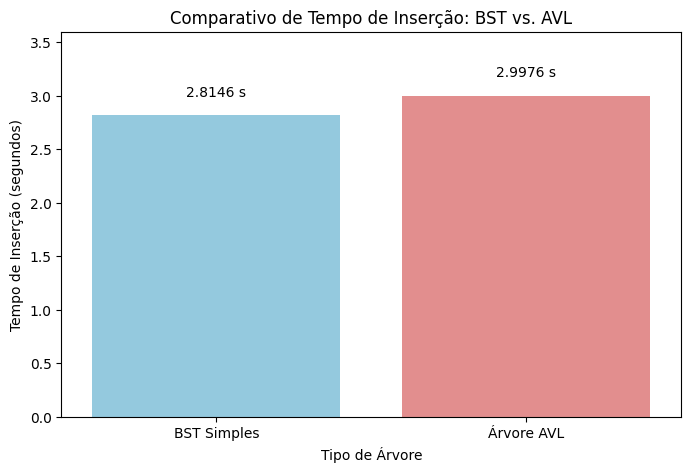

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o gráfico de tempo de inserção
insertion_times = {'BST Simples': time_bst_insert, 'Árvore AVL': time_avl_insert}
tree_types_insert = list(insertion_times.keys())
insert_values = list(insertion_times.values())

# Criar o gráfico de barras para tempo de inserção
plt.figure(figsize=(8, 5))
sns.barplot(x=tree_types_insert, y=insert_values, palette=['skyblue', 'lightcoral'], hue=tree_types_insert, legend=False)

# Adicionar títulos e rótulos
plt.title('Comparativo de Tempo de Inserção: BST vs. AVL')
plt.ylabel('Tempo de Inserção (segundos)')
plt.xlabel('Tipo de Árvore')

# Adicionar os valores nas barras
for index, value in enumerate(insert_values):
    plt.text(index, value + (max(insert_values) * 0.05), f'{value:.4f} s', ha='center', va='bottom')

plt.ylim(0, max(insert_values) * 1.2) # Ajustar o limite Y para melhor visualização
plt.show()

### Comparativo de Tempo de Inserção de um Único Novo Dado

In [19]:
import time


max_host_id = df_clean['host_id'].max()
new_host_id = int(max_host_id) + 1

new_data_dict = {
    'name': 'Novo Apartamento de Teste',
    'host_name': 'Host Teste',
    'neighbourhood': 'Bairro Teste',
    'room_type': 'Private room',
    'number_of_reviews': 0,
    'availability_365': 365,
    'price': 150.0
}

print(f"Preparando para inserir um novo dado (host_id: {new_host_id}) em ambas as árvores...")

# --- Medir tempo de inserção de um único dado na BST ---
start_time_bst_single_insert = time.time()
bst_price.insert(new_host_id, new_data_dict)
end_time_bst_single_insert = time.time()
time_bst_single_insert = (end_time_bst_single_insert - start_time_bst_single_insert) * 1000 # em milissegundos

# --- Medir tempo de inserção de um único dado na AVL ---
start_time_avl_single_insert = time.time()
# A função insert da AVL retorna a nova raiz (ou a mesma se nada mudar na raiz)
root = avl.insert(root, new_host_id, new_data_dict)
end_time_avl_single_insert = time.time()
time_avl_single_insert = (end_time_avl_single_insert - start_time_avl_single_insert) * 1000 # em milissegundos

print("\n=== Comparativo de Tempo de Inserção de um Único Novo Dado ===")
print(f"Tempo de inserção de 1 dado na BST Simples: {time_bst_single_insert:.4f} ms")
print(f"Tempo de inserção de 1 dado na Árvore AVL:  {time_avl_single_insert:.4f} ms")

Preparando para inserir um novo dado (host_id: 720801158) em ambas as árvores...

=== Comparativo de Tempo de Inserção de um Único Novo Dado ===
Tempo de inserção de 1 dado na BST Simples: 0.1841 ms
Tempo de inserção de 1 dado na Árvore AVL:  0.1609 ms


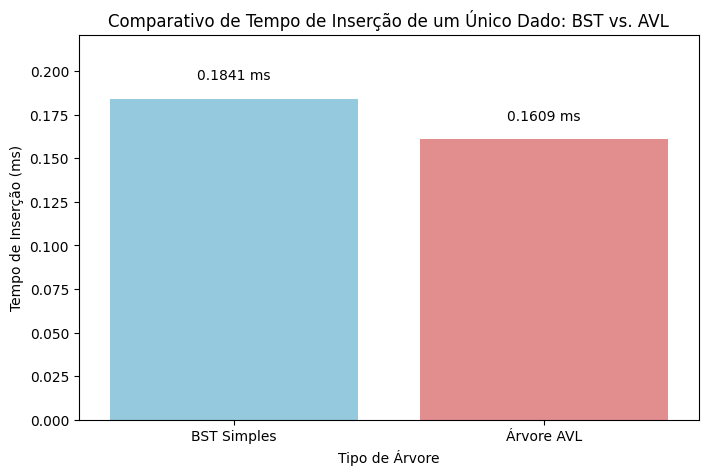

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o gráfico de tempo de inserção de um único dado
single_insertion_times = {'BST Simples': time_bst_single_insert, 'Árvore AVL': time_avl_single_insert}
tree_types_single_insert = list(single_insertion_times.keys())
single_insert_values = list(single_insertion_times.values())

# Criar o gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x=tree_types_single_insert, y=single_insert_values, palette=['skyblue', 'lightcoral'], hue=tree_types_single_insert, legend=False)

# Adicionar títulos e rótulos
plt.title('Comparativo de Tempo de Inserção de um Único Dado: BST vs. AVL')
plt.ylabel('Tempo de Inserção (ms)')
plt.xlabel('Tipo de Árvore')

# Adicionar os valores nas barras
for index, value in enumerate(single_insert_values):
    plt.text(index, value + (max(single_insert_values) * 0.05), f'{value:.4f} ms', ha='center', va='bottom')

plt.ylim(0, max(single_insert_values) * 1.2) # Ajustar o limite Y para melhor visualização
plt.show()

### Comparativo de Tempo de Remoção de um Único Novo Dado

In [21]:
import time


print(f"Preparando para remover o dado (host_id: {new_host_id}) de ambas as árvores...")

# --- Medir tempo de remoção de um único dado na BST ---
start_time_bst_single_delete = time.time()
bst_price.delete(new_host_id)
end_time_bst_single_delete = time.time()
time_bst_single_delete = (end_time_bst_single_delete - start_time_bst_single_delete) * 1000 # em milissegundos

# --- Medir tempo de remoção de um único dado na AVL ---
start_time_avl_single_delete = time.time()
root = avl.delete(root, new_host_id)
end_time_avl_single_delete = time.time()
time_avl_single_delete = (end_time_avl_single_delete - start_time_avl_single_delete) * 1000 # em milissegundos

print("\n=== Comparativo de Tempo de Remoção de um Único Novo Dado ===")
print(f"Tempo de remoção de 1 dado na BST Simples: {time_bst_single_delete:.4f} ms")
print(f"Tempo de remoção de 1 dado na Árvore AVL:  {time_avl_single_delete:.4f} ms")


Preparando para remover o dado (host_id: 720801158) de ambas as árvores...

=== Comparativo de Tempo de Remoção de um Único Novo Dado ===
Tempo de remoção de 1 dado na BST Simples: 0.2706 ms
Tempo de remoção de 1 dado na Árvore AVL:  0.1247 ms


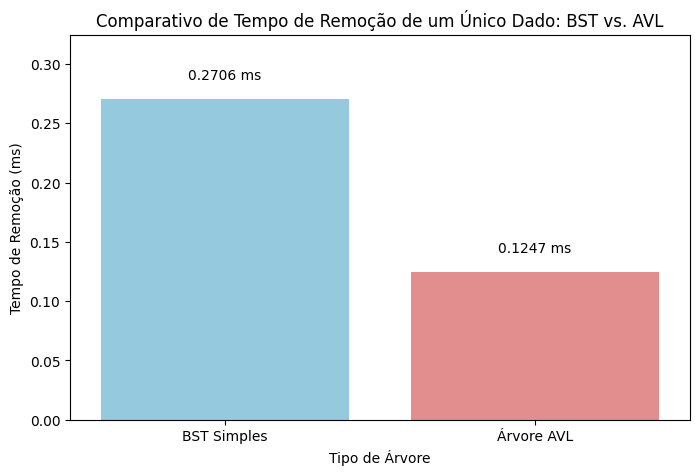

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados para o gráfico de tempo de remoção de um único dado
single_deletion_times = {'BST Simples': time_bst_single_delete, 'Árvore AVL': time_avl_single_delete}
tree_types_single_delete = list(single_deletion_times.keys())
single_delete_values = list(single_deletion_times.values())

# Criar o gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(x=tree_types_single_delete, y=single_delete_values, palette=['skyblue', 'lightcoral'], hue=tree_types_single_delete, legend=False)

# Adicionar títulos e rótulos
plt.title('Comparativo de Tempo de Remoção de um Único Dado: BST vs. AVL')
plt.ylabel('Tempo de Remoção (ms)')
plt.xlabel('Tipo de Árvore')

# Adicionar os valores nas barras
for index, value in enumerate(single_delete_values):
    plt.text(index, value + (max(single_delete_values) * 0.05), f'{value:.4f} ms', ha='center', va='bottom')

plt.ylim(0, max(single_delete_values) * 1.2) # Ajustar o limite Y para melhor visualização
plt.show()

### Tabela Resumo dos Tempos Médios de Operação

In [32]:
import pandas as pd
import time
import random
import sys


df = pd.read_csv('dataset.csv')
df_clean = df.dropna(subset=['price']).copy()

bst_price = BinarySearchTree()
for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'], 'host_name': row['host_name'], 'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'], 'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'], 'price': row['price']
    }
    bst_price.insert(row['host_id'], data_dict)

avl = AVLTree()
root = None
# Increase recursion limit for AVL insertion if it was reset
sys.setrecursionlimit(max(sys.getrecursionlimit(), len(df_clean) + 1000))
for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'], 'host_name': row['host_name'], 'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'], 'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'], 'price': row['price']
    }
    root = avl.insert(root, row['host_id'], data_dict)

# --- Re-executing Search Time Calculations ---
num_tests = 1000
times_bst = []
times_avl = []
search_host_ids = df_clean['host_id'].sample(num_tests, random_state=42).tolist()

for i in range(num_tests):
    target_host_id = search_host_ids[i]
    start_time_bst = time.time()
    bst_price.search_by_host_id(target_host_id)
    end_time_bst = time.time()
    times_bst.append((end_time_bst - start_time_bst) * 1000)

    start_time_avl = time.time()
    avl.search_by_host_id(root, target_host_id)
    end_time_avl = time.time()
    times_avl.append((end_time_avl - start_time_avl) * 1000)
avg_time_bst = sum(times_bst) / num_tests
avg_time_avl = sum(times_avl) / num_tests

# --- Re-executing Total Insertion Time Calculations ---
bst_insert_test = BinarySearchTree()
start_time_bst_insert = time.time()
for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'], 'host_name': row['host_name'], 'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'], 'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'], 'price': row['price']
    }
    bst_insert_test.insert(row['host_id'], data_dict)
end_time_bst_insert = time.time()
time_bst_insert = end_time_bst_insert - start_time_bst_insert

avl_insert_test = AVLTree()
root_insert_test = None
# Increase recursion limit for AVL insertion if it was reset
sys.setrecursionlimit(max(sys.getrecursionlimit(), len(df_clean) + 1000))
start_time_avl_insert = time.time()
for _, row in df_clean.iterrows():
    data_dict = {
        'name': row['name'], 'host_name': row['host_name'], 'neighbourhood': row['neighbourhood'],
        'room_type': row['room_type'], 'number_of_reviews': row['number_of_reviews'],
        'availability_365': row['availability_365'], 'price': row['price']
    }
    root_insert_test = avl_insert_test.insert(root_insert_test, row['host_id'], data_dict)
end_time_avl_insert = time.time()
time_avl_insert = end_time_avl_insert - start_time_avl_insert

# --- Re-executing Single Insertion Time Calculations ---
max_host_id = df_clean['host_id'].max()
new_host_id = int(max_host_id) + 1
new_data_dict = {
    'name': 'Novo Apartamento de Teste', 'host_name': 'Host Teste', 'neighbourhood': 'Bairro Teste',
    'room_type': 'Private room', 'number_of_reviews': 0, 'availability_365': 365, 'price': 150.0
}
start_time_bst_single_insert = time.time()
bst_price.insert(new_host_id, new_data_dict)
end_time_bst_single_insert = time.time()
time_bst_single_insert = (end_time_bst_single_insert - start_time_bst_single_insert) * 1000

start_time_avl_single_insert = time.time()
root = avl.insert(root, new_host_id, new_data_dict)
end_time_avl_single_insert = time.time()
time_avl_single_insert = (end_time_avl_single_insert - start_time_avl_single_insert) * 1000

# --- Re-executing Single Deletion Time Calculations ---
start_time_bst_single_delete = time.time()
bst_price.delete(new_host_id)
end_time_bst_single_delete = time.time()
time_bst_single_delete = (end_time_bst_single_delete - start_time_bst_single_delete) * 1000

start_time_avl_single_delete = time.time()
root = avl.delete(root, new_host_id)
end_time_avl_single_delete = time.time()
time_avl_single_delete = (end_time_avl_single_delete - start_time_avl_single_delete) * 1000

# --- Summary Table Generation ---
summary_data = {
    'Operação': ['Busca (média)', 'Inserção (total)', 'Inserção (única)', 'Remoção (única)'],
    'BST Simples (ms/s)': [
        avg_time_bst,
        time_bst_insert,
        time_bst_single_insert,
        time_bst_single_delete
    ],
    'Árvore AVL (ms/s)': [
        avg_time_avl,
        time_avl_insert,
        time_avl_single_insert,
        time_avl_single_delete
    ]
}

summary_df = pd.DataFrame(summary_data)

# Formatando para exibição: ms para buscas e operações únicas, segundos para inserção total
summary_df.loc[0, 'BST Simples (ms/s)'] = f"{summary_df.loc[0, 'BST Simples (ms/s)']:.4f} ms"
summary_df.loc[0, 'Árvore AVL (ms/s)'] = f"{summary_df.loc[0, 'Árvore AVL (ms/s)']:.4f} ms"

summary_df.loc[1, 'BST Simples (ms/s)'] = f"{summary_df.loc[1, 'BST Simples (ms/s)']:.4f} s"
summary_df.loc[1, 'Árvore AVL (ms/s)'] = f"{summary_df.loc[1, 'Árvore AVL (ms/s)']:.4f} s"

summary_df.loc[2, 'BST Simples (ms/s)'] = f"{summary_df.loc[2, 'BST Simples (ms/s)']:.4f} ms"
summary_df.loc[2, 'Árvore AVL (ms/s)'] = f"{summary_df.loc[2, 'Árvore AVL (ms/s)']:.4f} ms"

summary_df.loc[3, 'BST Simples (ms/s)'] = f"{summary_df.loc[3, 'BST Simples (ms/s)']:.4f} ms"
summary_df.loc[3, 'Árvore AVL (ms/s)'] = f"{summary_df.loc[3, 'Árvore AVL (ms/s)']:.4f} ms"

display(summary_df)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(


/tmp/ipykernel_4013/3099252962.py:139: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0050 ms' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[0, 'BST Simples (ms/s)'] = f"{summary_df.loc[0, 'BST Simples (ms/s)']:.4f} ms"
/tmp/ipykernel_4013/3099252962.py:140: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.0033 ms' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  summary_df.loc[0, 'Árvore AVL (ms/s)'] = f"{summary_df.loc[0, 'Árvore AVL (ms/s)']:.4f} ms"


,Operação,BST Simples (ms/s),Árvore AVL (ms/s)
0,Busca (média),0.0050 ms,0.0033 ms
1,Inserção (total),2.6187 s,3.2600 s
2,Inserção (única),0.1192 ms,0.0975 ms
3,Remoção (única),0.1729 ms,0.0806 ms


##Data Science

### Preço Médio para apartamentos inteiros disponíveis para aluguel por Bairro

In [23]:
# 1. Filtrar o DataFrame para 'Entire home/apt'
entire_home_apt_df = df_clean[df_clean['room_type'] == 'Entire home/apt'].copy()

# 2. Calcular o preço médio por bairro
average_price_by_neighbourhood = entire_home_apt_df.groupby('neighbourhood')['price'].mean().reset_index()

# 3. Ordenar os resultados para melhor visualização (opcional)
average_price_by_neighbourhood = average_price_by_neighbourhood.sort_values(by='price', ascending=False)

# 4. Criar e exibir a tabela
print("Preço médio de 'Entire home/apt' por bairro:")
display(average_price_by_neighbourhood.head(10)) # Exibir os 10 bairros com os preços mais altos
display(average_price_by_neighbourhood.tail(10)) # Exibir os 10 bairros com os preços mais baixos

Preço médio de 'Entire home/apt' por bairro:


,neighbourhood,price
42,Estácio,18125.357143
69,Joá,7526.951389
123,São Conrado,5004.765714
29,Coelho Neto,3822.333333
62,Itanhangá,2685.383178
2,Anchieta,2531.000000
99,Portuguesa,2375.333333
33,Cosme Velho,1876.636364
118,Santíssimo,1788.428571
30,Colégio,1592.000000


,neighbourhood,price
108,Ribeira,144.000000
138,Vicente de Carvalho,140.000000
44,Freguesia (Ilha),133.000000
89,Parada de Lucas,130.000000
76,Magalhães Bastos,121.000000
142,Vila Militar,120.250000
121,Senador Vasconcelos,105.285714
24,Cavalcanti,98.125000
80,Maria da Graça,93.000000
40,Engenho da Rainha,74.000000


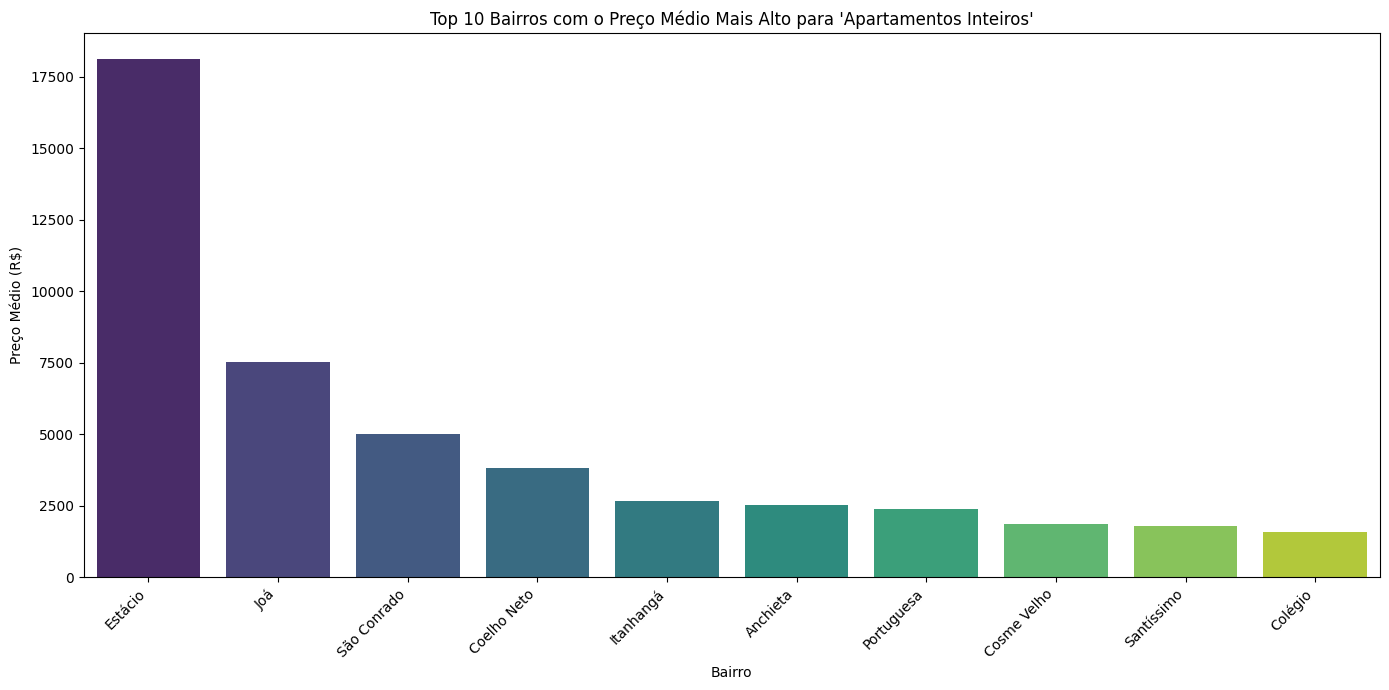

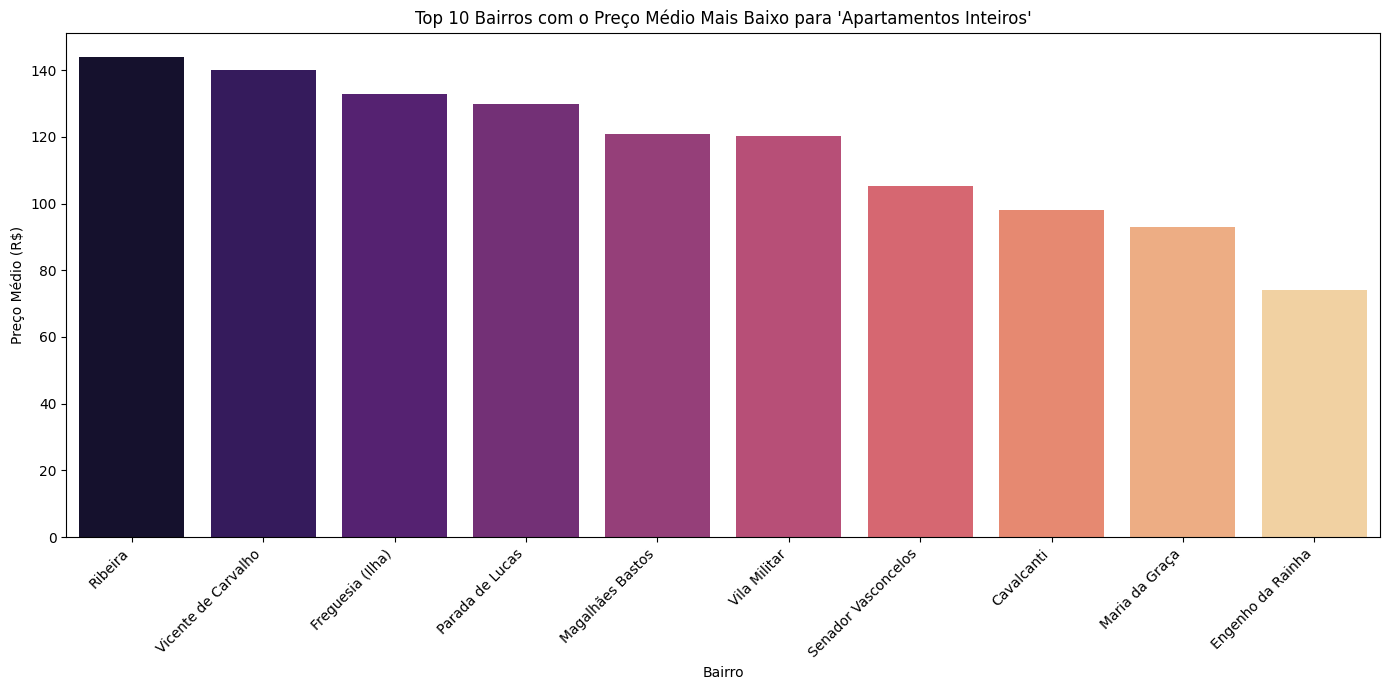

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o gráfico de barras para os 10 bairros mais caros
plt.figure(figsize=(14, 7))
sns.barplot(x='neighbourhood', y='price', data=average_price_by_neighbourhood.head(10), palette='viridis', hue='neighbourhood', legend=False)
plt.title('Top 10 Bairros com o Preço Médio Mais Alto para \'Apartamentos Inteiros\'')
plt.xlabel('Bairro')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Criar o gráfico de barras para os 10 bairros mais baratos
plt.figure(figsize=(14, 7))
sns.barplot(x='neighbourhood', y='price', data=average_price_by_neighbourhood.tail(10), palette='magma', hue='neighbourhood', legend=False)
plt.title('Top 10 Bairros com o Preço Médio Mais Baixo para \'Apartamentos Inteiros\'')
plt.xlabel('Bairro')
plt.ylabel('Preço Médio (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análise dos Top 10 Anfitriões por Quantidade de Imóveis e Preço Médio

In [25]:
# Agrupar por host_name e calcular a quantidade de imóveis e o preço médio
host_analysis = df_clean.groupby('host_name').agg(
    num_properties=('id', 'count'),
    avg_price=('price', 'mean')
).reset_index()

# Ordenar para encontrar os top 10 hosts com mais propriedades
top_10_hosts = host_analysis.sort_values(by='num_properties', ascending=False).head(10)

print("Top 10 Anfitriões por Quantidade de Imóveis e Preço Médio:")
display(top_10_hosts)

Top 10 Anfitriões por Quantidade de Imóveis e Preço Médio:


,host_name,num_properties,avg_price
1412,Daniel,410,619.173171
5929,Rodrigo,370,595.686486
5666,Rafael,324,579.114198
2194,Felipe,274,602.503650
2212,Fernanda,271,492.988930
843,Bruno,268,1085.645522
5843,Ricardo,265,2543.626415
3554,Juliana,256,563.828125
5569,Pedro,256,572.171875
4382,Marcelo,246,990.487805


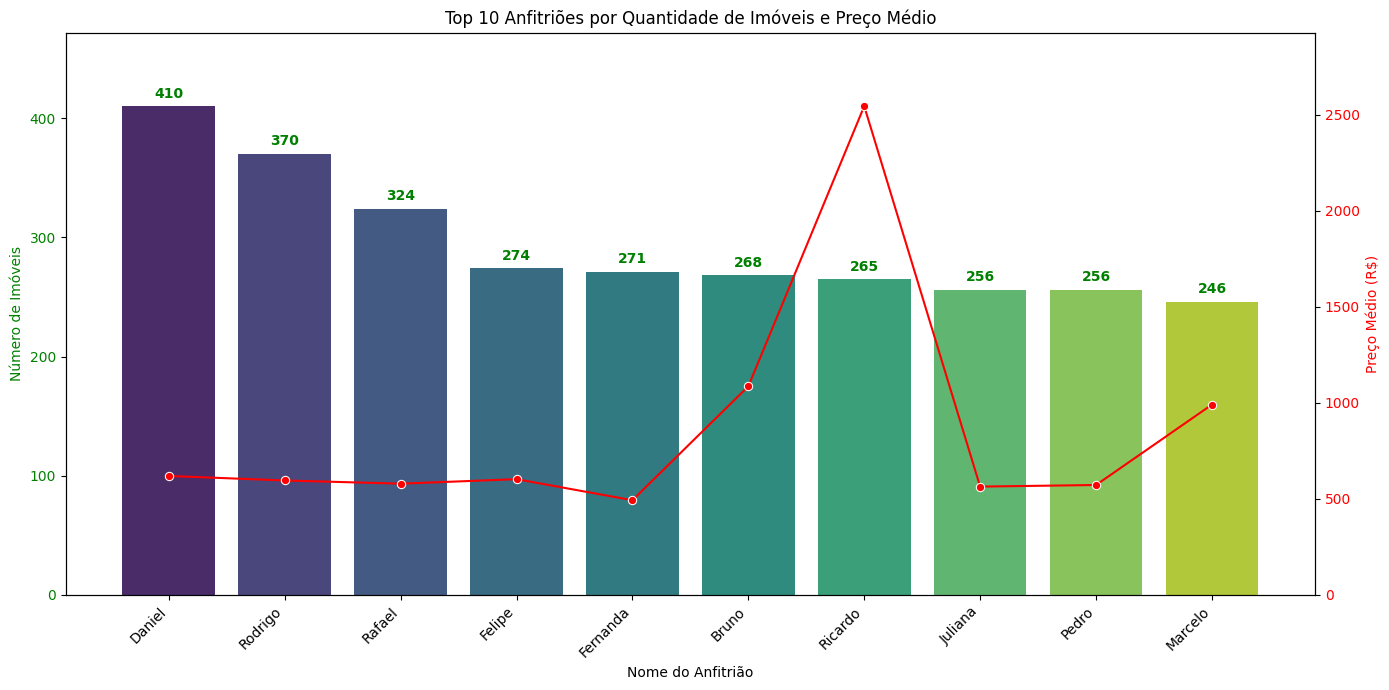

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração da figura
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Plotagem das Barras (Número de Imóveis)
bar_plot = sns.barplot(
    x='host_name',
    y='num_properties',
    data=top_10_hosts,
    palette='viridis',
    hue='host_name',
    legend=False,
    ax=ax1
)

# Adicionar rótulos no topo das barras
for p in bar_plot.patches:
    ax1.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   color='green', fontweight='bold')

ax1.set_title('Top 10 Anfitriões por Quantidade de Imóveis e Preço Médio')
ax1.set_xlabel('Nome do Anfitrião')
ax1.set_ylabel('Número de Imóveis', color='g')
ax1.tick_params(axis='y', labelcolor='g')
ax1.set_xticks(range(len(top_10_hosts)))
ax1.set_xticklabels(top_10_hosts['host_name'], rotation=45, ha='right')

# 2. Criação do segundo eixo e Linha (Preço Médio)
ax2 = ax1.twinx()
line_plot = sns.lineplot(
    x='host_name',
    y='avg_price',
    data=top_10_hosts,
    color='red',
    marker='o',
    sort=False,
    ax=ax2
)

# Adicionar rótulos nos pontos da linha
for i, row in top_10_hosts.iterrows():
    ax2.annotate(f"R$ {row['avg_price']:.2f}",
                   (i, row['avg_price']),
                   textcoords="offset points",
                   xytext=(0, 10),
                   ha='center',
                   color='red', fontweight='bold')

ax2.set_ylabel('Preço Médio (R$)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Ajustar os limites do eixo Y para os rótulos não cortarem no topo
ax1.set_ylim(0, top_10_hosts['num_properties'].max() * 1.15)
ax2.set_ylim(0, top_10_hosts['avg_price'].max() * 1.15)

plt.tight_layout()
plt.show()

### Análise da Relação entre Número de Reviews e Preço

Correlação entre 'Número de Reviews' e 'Preço': -0.04


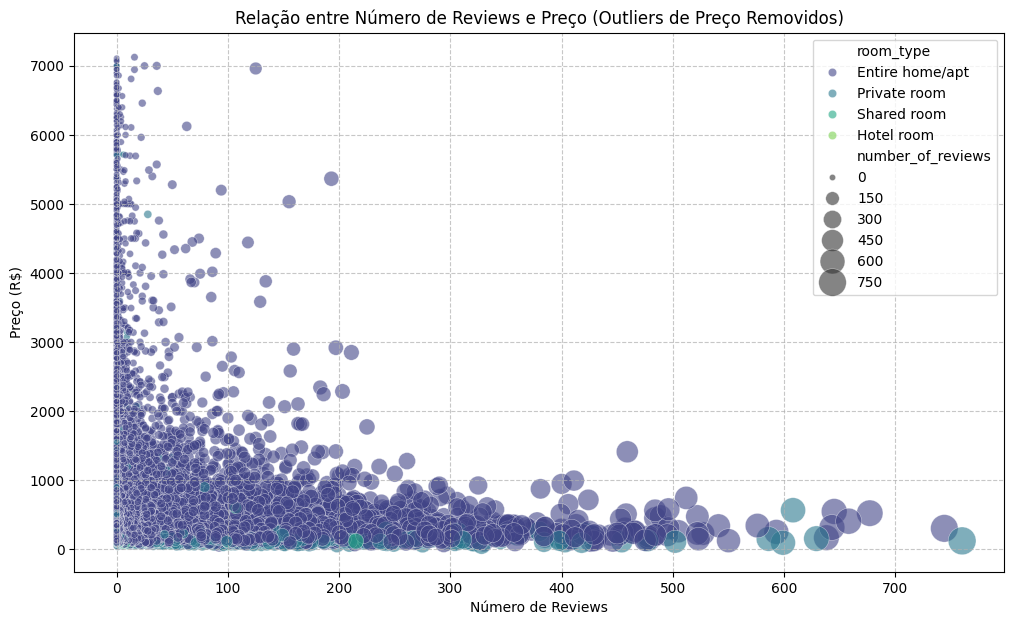

In [27]:
# Calcular a correlação entre 'number_of_reviews' e 'price'
correlation = df_clean['number_of_reviews'].corr(df_clean['price'])

print(f"Correlação entre 'Número de Reviews' e 'Preço': {correlation:.2f}")

# Filtrar para remover outliers extremos no preço, se necessário, para melhor visualização
# (ex: preços muito altos podem distorcer o scatter plot)
df_viz = df_clean[df_clean['price'] < df_clean['price'].quantile(0.99)] # Remover 1% dos preços mais altos

plt.figure(figsize=(12, 7))
sns.scatterplot(x='number_of_reviews', y='price', data=df_viz, alpha=0.6, hue='room_type', palette='viridis', size='number_of_reviews', sizes=(20, 400))
plt.title('Relação entre Número de Reviews e Preço (Outliers de Preço Removidos)')
plt.xlabel('Número de Reviews')
plt.ylabel('Preço (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análise da Relação entre Disponibilidade e Preço

Correlação entre 'Disponibilidade (availability_365)' e 'Preço': 0.05


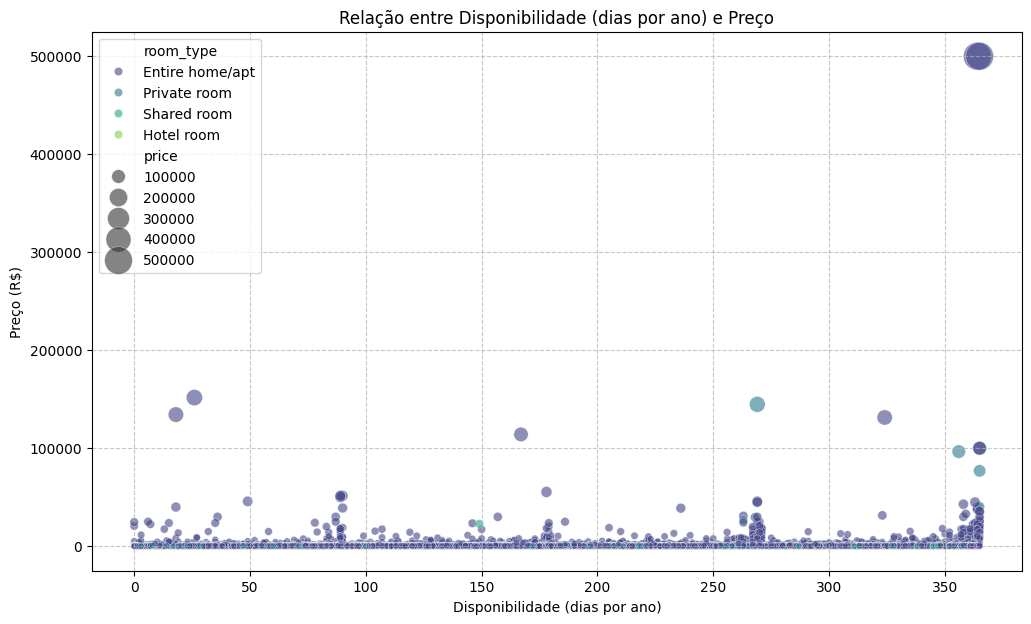

In [28]:
# Calcular a correlação entre 'availability_365' e 'price'
correlation_availability_price = df_clean['availability_365'].corr(df_clean['price'])

print(f"Correlação entre 'Disponibilidade (availability_365)' e 'Preço': {correlation_availability_price:.2f}")

# Visualizar a relação com um scatter plot
plt.figure(figsize=(12, 7))
sns.scatterplot(x='availability_365', y='price', data=df_clean, alpha=0.6, hue='room_type', palette='viridis', size='price', sizes=(20, 400))
plt.title('Relação entre Disponibilidade (dias por ano) e Preço')
plt.xlabel('Disponibilidade (dias por ano)')
plt.ylabel('Preço (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Bairros com Maior Densidade de Imóveis na Faixa de Preço de 300 a 500 reais

In [29]:
# 1. Filtrar o DataFrame para imóveis na faixa de R$ 300 a R$ 500
price_range_df = df_clean[(df_clean['price'] >= 300) & (df_clean['price'] <= 500)].copy()

# 2. Agrupar por bairro e contar a quantidade de imóveis
neighbourhood_density = price_range_df.groupby('neighbourhood').agg(
    property_count=('id', 'count')
).reset_index()

# 3. Ordenar os resultados pela contagem de imóveis em ordem decrescente
neighbourhood_density_sorted = neighbourhood_density.sort_values(by='property_count', ascending=False)

# 4. Exibir os top 10 bairros com a maior densidade
print("Top 10 Bairros com a Maior Densidade de Imóveis na Faixa de R$ 300 a R$ 500:")
display(neighbourhood_density_sorted.head(10))

Top 10 Bairros com a Maior Densidade de Imóveis na Faixa de R$ 300 a R$ 500:


,neighbourhood,property_count
24,Copacabana,3484
43,Ipanema,1091
5,Barra da Tijuca,1049
76,Recreio dos Bandeirantes,496
54,Leblon,484
46,Jacarepaguá,384
9,Botafogo,364
83,Santa Teresa,223
55,Leme,202
32,Flamengo,193


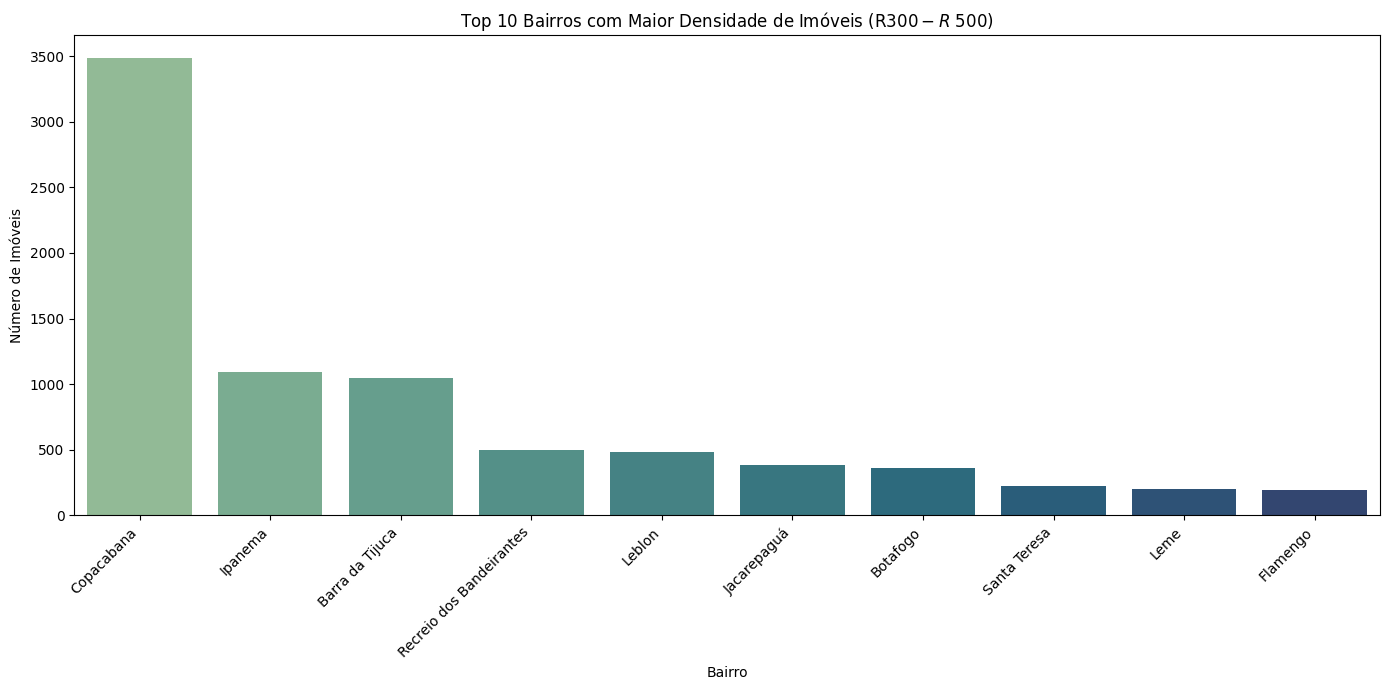

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar o gráfico de barras para os top 10 bairros
plt.figure(figsize=(14, 7))
sns.barplot(x='neighbourhood', y='property_count', data=neighbourhood_density_sorted.head(10), palette='crest', hue='neighbourhood', legend=False)
plt.title('Top 10 Bairros com Maior Densidade de Imóveis (R$ 300 - R$ 500)')
plt.xlabel('Bairro')
plt.ylabel('Número de Imóveis')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Busca por Campos que não sejam a Chave

### Busca Linear

In [6]:
def search_by_host_name(tree_root, target_name):
    """
    Busca um imóvel pelo nome do anfitrião.
    Como a árvore está ordenada por HOST_ID, esta busca exige
    percorrer a árvore inteira (Complexidade O(n)).
    """
    if tree_root is None:
        return None

    # Verifica o nó atual
    if tree_root.info['host_name'] == target_name:
        return tree_root.info

    # Busca na subárvore esquerda
    res_left = search_by_host_name(tree_root.left, target_name)
    if res_left: return res_left

    # Busca na subárvore direita
    return search_by_host_name(tree_root.right, target_name)

# Exemplo de uso:
anfitriao = "Katrina"
resultado = search_by_host_name(root, anfitriao)
if resultado:
    print(f"Encontrado imóvel para o anfitrião {anfitriao}: {resultado}")
else:
    print(f"Nenhum imóvel encontrado para o anfitrião {anfitriao}.")

Encontrado imóvel para o anfitrião Katrina: {'name': 'Bright and Peaceful Leblon Loft', 'host_name': 'Katrina', 'neighbourhood': 'Leblon', 'room_type': 'Entire home/apt', 'number_of_reviews': 86, 'availability_365': 82, 'price': 580.0}


### Busca Eficiente - Índice Secundário

#### Implementando o Índice Secundário (BST para Host Name)

In [8]:
class SecondaryIndexNode:
    def __init__(self, key, primary_key_value):
        self.key = key
        self.primary_keys = [primary_key_value]
        self.left = None
        self.right = None

class SecondaryIndexBST:
    def __init__(self):
        self.root = None

    def insert(self, key, primary_key_value):
        new_node = SecondaryIndexNode(key, primary_key_value)
        if self.root is None:
            self.root = new_node
            return

        current = self.root
        while True:
            if key < current.key:
                if current.left is None:
                    current.left = new_node
                    break
                current = current.left
            elif key > current.key:
                if current.right is None:
                    current.right = new_node
                    break
                current = current.right
            else:  # Chave já existe, adicione o valor da chave primária
                current.primary_keys.append(primary_key_value)
                break

    def search(self, key):
        current = self.root
        while current is not None:
            if key == current.key:
                return current.primary_keys
            elif key < current.key:
                current = current.left
            else:
                current = current.right
        return []  # Retorna lista vazia se a chave não for encontrada

#### Construindo Índices Secundários

In [10]:
secondary_index_bst = SecondaryIndexBST()

# Limpar e converter host_name para string antes de construir o índice
df_clean['host_name_str'] = df_clean['host_name'].fillna('Undefined Host').astype(str)

print("Construindo índice secundário para host_name...")
for _, row in df_clean.iterrows():
    secondary_index_bst.insert(row['host_name_str'], row['host_id'])
print("Índice secundário para host_name construído com sucesso.")

Construindo índice secundário para host_name...
Índice secundário para host_name construído com sucesso.


In [11]:
def search_by_host_name_efficient(secondary_index_tree, primary_tree, target_name):
    """
    Busca imóveis pelo nome do anfitrião usando o índice secundário.
    Retorna uma lista de dicionários de informações dos imóveis.
    """
    # 1. Busca no índice secundário para obter os host_ids
    host_ids_found = secondary_index_tree.search(target_name)

    results = []
    if host_ids_found:
        # 2. Para cada host_id encontrado, busca na árvore primária
        for host_id in host_ids_found:

            info = primary_tree.search_by_host_id(host_id) # Usando a BST principal
            if info:
                results.append(info)
    return results

# Exemplo de uso com o índice secundário:
anfitriao = "Katrina"
# Usando bst_price como árvore primária para buscar os detalhes completos
resultados_eficientes = search_by_host_name_efficient(secondary_index_bst, bst_price, anfitriao)

if resultados_eficientes:
    print(f"Encontrados {len(resultados_eficientes)} imóveis para o anfitrião {anfitriao}:")
    for res in resultados_eficientes:
        print(res)
else:
    print(f"Nenhum imóvel encontrado para o anfitrião {anfitriao}.")

Encontrados 1 imóveis para o anfitrião Katrina:
{'name': 'Bright and Peaceful Leblon Loft', 'host_name': 'Katrina', 'neighbourhood': 'Leblon', 'room_type': 'Entire home/apt', 'number_of_reviews': 86, 'availability_365': 82, 'price': 580.0}


#### Comparação de Performance: Busca Linear vs. Busca com Índice Secundário


=== Comparativo de Tempo de Busca por Host Name para 'Katrina' ===
Tempo de busca linear (BST): 11.9777 ms
Tempo de busca com índice secundário (BST): 0.0784 ms


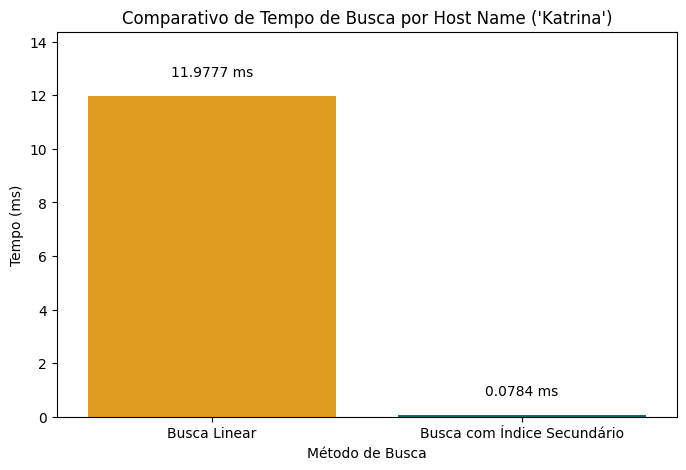

In [12]:
import time

# Para a busca linear, podemos usar a função anterior ou adaptar uma para ser iterativa
def search_by_host_name_linear(tree_root, target_name):
    results = []
    if tree_root is None:
        return results

    queue = deque([tree_root]) # Usar deque para busca em largura
    visited = set()

    while queue:
        current_node = queue.popleft()
        if current_node.host_id in visited: # Evitar ciclos ou reprocessar
            continue
        visited.add(current_node.host_id)

        if current_node.info['host_name'] == target_name:
            results.append(current_node.info)

        if current_node.left:
            queue.append(current_node.left)
        if current_node.right:
            queue.append(current_node.right)
    return results

target_anfitriao = "Katrina"

# Medir tempo da busca linear
start_time_linear = time.time()
linear_results = search_by_host_name_linear(bst_price.root, target_anfitriao)
end_time_linear = time.time()
time_linear = (end_time_linear - start_time_linear) * 1000

# Medir tempo da busca eficiente
start_time_efficient = time.time()
efficient_results = search_by_host_name_efficient(secondary_index_bst, bst_price, target_anfitriao)
end_time_efficient = time.time()
time_efficient = (end_time_efficient - start_time_efficient) * 1000

print(f"\n=== Comparativo de Tempo de Busca por Host Name para '{target_anfitriao}' ===")
print(f"Tempo de busca linear (BST): {time_linear:.4f} ms")
print(f"Tempo de busca com índice secundário (BST): {time_efficient:.4f} ms")

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

times = {'Busca Linear': time_linear, 'Busca com Índice Secundário': time_efficient}
labels = list(times.keys())
values = list(times.values())

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=values, palette=['orange', 'teal'], hue=labels, legend=False)
plt.title(f"Comparativo de Tempo de Busca por Host Name ('{target_anfitriao}')")
plt.ylabel('Tempo (ms)')
plt.xlabel('Método de Busca')
for index, value in enumerate(values):
    plt.text(index, value + (max(values) * 0.05), f'{value:.4f} ms', ha='center', va='bottom')
plt.ylim(0, max(values) * 1.2)
plt.show()